In [ ]:
import os

folders = [
    "/content/cotton-smart-farming/data",
    "/content/cotton-smart-farming/models",
    "/content/cotton-smart-farming/notebooks",
    "/content/cotton-smart-farming/results",
    "/content/cotton-smart-farming/src"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

checkpoint_dir = '/content/drive/MyDrive/cotton_disease_checkpoints/'
os.makedirs(checkpoint_dir, exist_ok=True)
print("Checkpoints will be saved to:", checkpoint_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoints will be saved to: /content/drive/MyDrive/cotton_disease_checkpoints/


In [ ]:
!pip install tensorflow matplotlib seaborn scikit-learn opencv-python

In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!kaggle datasets download -d saeedazfar/customized-cotton-disease-dataset
!unzip customized-cotton-disease-dataset.zip -d /content/cotton-smart-farming/data/

Dataset URL: https://www.kaggle.com/datasets/saeedazfar/customized-cotton-disease-dataset
License(s): unknown
customized-cotton-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  customized-cotton-disease-dataset.zip
replace /content/cotton-smart-farming/data/Cotton-Disease-Training/trainning/Cotton leaves - Training/800 Images/Aphids/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

base_path = "/content/cotton-smart-farming/data"

for root, dirs, files in os.walk(base_path):
    print(root)

/content/cotton-smart-farming/data
/content/cotton-smart-farming/data/Customized Cotton Dataset-Complete
/content/cotton-smart-farming/data/Customized Cotton Dataset-Complete/content
/content/cotton-smart-farming/data/Customized Cotton Dataset-Complete/content/validation
/content/cotton-smart-farming/data/Customized Cotton Dataset-Complete/content/validation/Cotton plant disease-Validation
/content/cotton-smart-farming/data/Customized Cotton Dataset-Complete/content/validation/Cotton plant disease-Validation/Cotton plant disease-Validation
/content/cotton-smart-farming/data/Customized Cotton Dataset-Complete/content/validation/Cotton plant disease-Validation/Cotton plant disease-Validation/Healthy leaf edited
/content/cotton-smart-farming/data/Customized Cotton Dataset-Complete/content/validation/Cotton plant disease-Validation/Cotton plant disease-Validation/Cotton Boll rot
/content/cotton-smart-farming/data/Customized Cotton Dataset-Complete/content/validation/Cotton plant disease-Va

In [ ]:
dataset_path = "/content/cotton-smart-farming/data/Customized Cotton Dataset-Complete/content/trainning/Cotton leaves - Training/800 Images"

In [ ]:
import os

class_counts = {}

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

print(class_counts)

{'Army worm': 800, 'Target spot': 788, 'Aphids': 800, 'Bacterial blight': 800, 'Cotton Boll Rot': 960, 'Green Cotton Boll': 880, 'Healthy': 800, 'Powdery mildew': 800}


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 5303 images belonging to 8 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1325 images belonging to 8 classes.


In [ ]:
print(train_generator.class_indices)

{'Aphids': 0, 'Army worm': 1, 'Bacterial blight': 2, 'Cotton Boll Rot': 3, 'Green Cotton Boll': 4, 'Healthy': 5, 'Powdery mildew': 6, 'Target spot': 7}


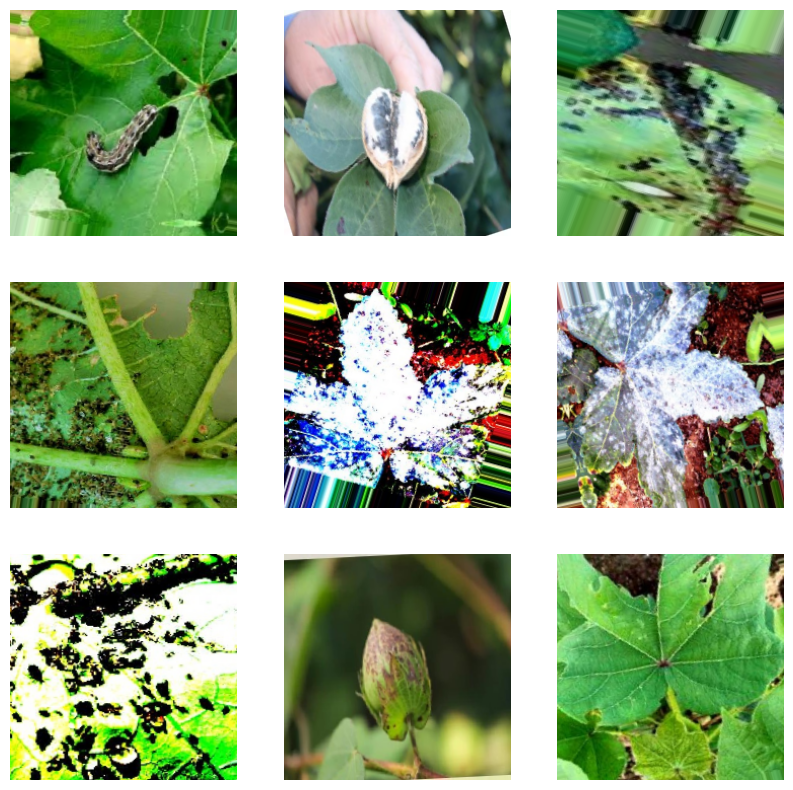

In [ ]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.axis("off")

plt.show()

# MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

In [ ]:
model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 139s 697ms/step - accuracy: 0.6838 - loss: 0.9237 - val_accuracy: 0.9411 - val_loss: 0.2399
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 100s 602ms/step - accuracy: 0.8529 - loss: 0.4328 - val_accuracy: 0.9547 - val_loss: 0.1507
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 99s 597ms/step - accuracy: 0.8904 - loss: 0.3199 - val_accuracy: 0.9653 - val_loss: 0.1121
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 100s 603ms/step - accuracy: 0.9033 - loss: 0.2818 - val_accuracy: 0.9804 - val_loss: 0.0785
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 98s 593ms/step - accuracy: 0.9131 - loss: 0.2493 - val_accuracy: 0.9789 - val_loss: 0.0834
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 99s 598ms/step - accuracy: 0.9238 - loss: 0.2172 - val_accuracy: 0.9789 - val_loss: 0.0719
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 129s 773ms/step - accuracy: 0.9329 - loss: 0.1977 - val_accuracy: 0.9811 - val_loss: 0.0635
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 105s 635ms/step - accuracy: 0.9351 - lo

In [ ]:
model.save("/content/cotton-smart-farming/models/cotton_model.keras")

In [ ]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 474ms/step - accuracy: 0.9857 - loss: 0.0453
Validation Accuracy: 0.9856603741645813


In [ ]:
import numpy as np

predictions = model.predict(validation_generator)
y_pred = np.argmax(predictions, axis=1)
confidence = float(np.max(predictions))  # 0–1

def get_severity(conf):
    if conf >= 0.80:
        return "Severe"
    elif conf >= 0.50:
        return "Moderate"
    else:
        return "Mild"

42/42 ━━━━━━━━━━━━━━━━━━━━ 32s 616ms/step


In [ ]:
y_true = validation_generator.classes

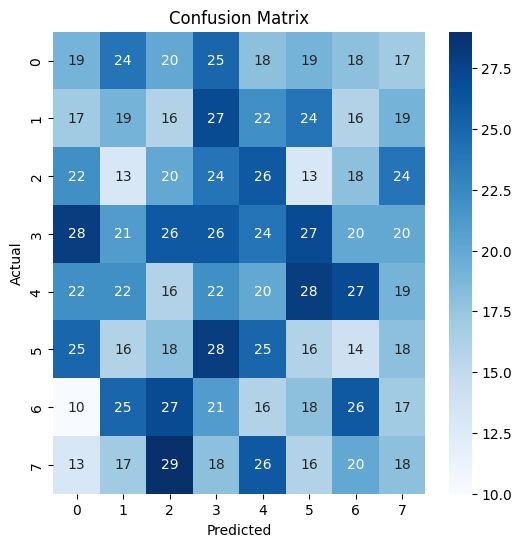

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

class_labels = list(validation_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

                   precision    recall  f1-score   support

           Aphids       0.12      0.12      0.12       160
        Army worm       0.12      0.12      0.12       160
 Bacterial blight       0.12      0.12      0.12       160
  Cotton Boll Rot       0.14      0.14      0.14       192
Green Cotton Boll       0.11      0.11      0.11       176
          Healthy       0.10      0.10      0.10       160
   Powdery mildew       0.16      0.16      0.16       160
      Target spot       0.12      0.11      0.12       157

         accuracy                           0.12      1325
        macro avg       0.12      0.12      0.12      1325
     weighted avg       0.12      0.12      0.12      1325



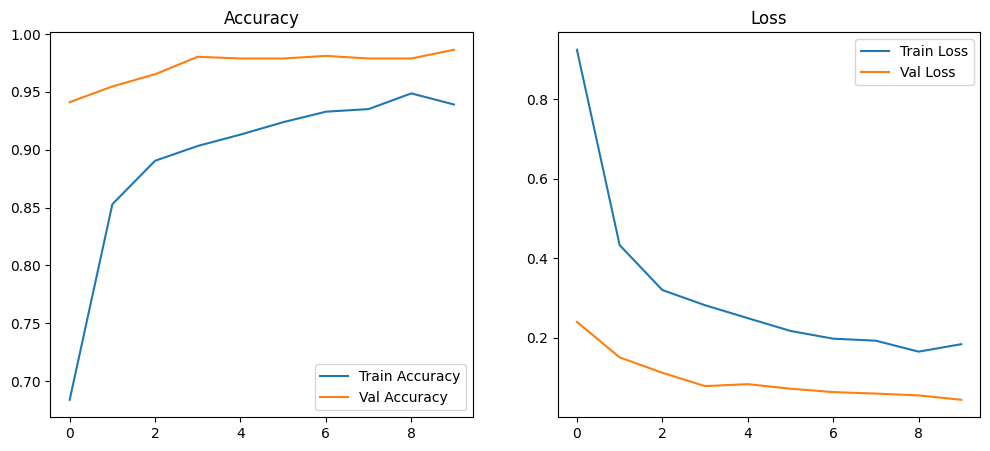

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab import files

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load model
model = load_model("/content/cotton-smart-farming/models/cotton_model.keras")

# Preprocess
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Correct labels
class_labels = [
    'Aphids',
    'Army worm',
    'Bacterial blight',
    'Cotton Boll Rot',
    'Green Cotton Boll',
    'Healthy',
    'Powdery mildew',
    'Target spot'
]

print("Predicted Disease:", class_labels[predicted_class])

severity = get_severity(confidence)
treatment_map = {
    "Aphids": "Use neem oil or imidacloprid spray.",
    "Army worm": "Apply biological control (Bt) or spinosad.",
    "Bacterial blight": "Use copper-based bactericides and resistant varieties.",
    "Cotton Boll Rot": "Ensure proper drainage and apply fungicide.",
    "Green Cotton Boll": "Monitor and manage pest infestation.",
    "Healthy": "No treatment needed.",
    "Powdery mildew": "Apply sulfur-based fungicide.",
    "Target spot": "Use appropriate fungicide and crop rotation."
}

disease = class_labels[predicted_class]
treatment = treatment_map.get(disease, "Consult expert.")

print(f"Disease: {class_labels[predicted_class]}")
print(f"Confidence: {confidence*100:.2f}%")
print(f"Severity: {severity}")
print(f"Treatment:", treatment)


Saving 0337.jpg to 0337 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Disease: Bacterial blight
Disease: Bacterial blight
Confidence: 100.00%
Severity: Severe
Treatment: Use copper-based bactericides and resistant varieties.


# Increased model efficiency MobileNetv2

In [ ]:
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization,
    LeakyReLU,
    Conv2D,
    Activation
)

from tensorflow.keras.regularizers import l2

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/cotton-smart-farming/models/best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [ ]:
x = base_model.output
x = Conv2D(
    128,
    (3,3),
    strides=(2,2),
    padding='same',
    kernel_regularizer=l2(0.001)
)(x)

In [ ]:
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)

In [ ]:
x = Activation('swish')(x)
x = GlobalAveragePooling2D()(x)

In [ ]:
x = Dense(
    512,
    kernel_regularizer=l2(0.001)
)(x)

x = BatchNormalization()(x)

x = LeakyReLU(alpha=0.1)(x)

x = Dropout(0.5)(x)

x = Dense(
    256,
    kernel_regularizer=l2(0.001)
)(x)

x = Activation('swish')(x)

x = Dropout(0.4)(x)

In [ ]:
output = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

In [ ]:
from tensorflow.keras.models import Model

model = Model(
    inputs=base_model.input,
    outputs=output
)

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/cotton-smart-farming/models/best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 155s 763ms/step - accuracy: 0.3338 - loss: 2.6582 - val_accuracy: 0.7555 - val_loss: 2.2803
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 104s 626ms/step - accuracy: 0.6279 - loss: 1.8802 - val_accuracy: 0.8717 - val_loss: 1.5644
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 102s 617ms/step - accuracy: 0.7443 - loss: 1.5777 - val_accuracy: 0.9253 - val_loss: 1.1789
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 103s 621ms/step - accuracy: 0.8052 - loss: 1.4188 - val_accuracy: 0.9374 - val_loss: 1.0457
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 124s 750ms/step - accuracy: 0.8446 - loss: 1.2920 - val_accuracy: 0.9555 - val_loss: 0.9838
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 102s 617ms/step - accuracy: 0.8627 - loss: 1.2297 - val_accuracy: 0.9721 - val_loss: 0.9295
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 102s 615ms/step - accuracy: 0.8795 - loss: 1.1756 - val_accuracy: 0.9728 - val_loss: 0.9078
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 104s 622ms/step - accuracy: 0.9044 -

In [ ]:
print("Before fine-tuning:", history.history['val_accuracy'][-1])
print("After fine-tuning:", history_fine.history['val_accuracy'][-1])

Before fine-tuning: 0.9788679480552673
After fine-tuning: 0.9901886582374573


In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

def grad_cam(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap.numpy()



In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [ ]:
def grad_cam(model, img_array, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        class_idx = tf.argmax(predictions[0])

        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    heatmap /= np.max(heatmap)

    return heatmap

In [ ]:
heatmap = grad_cam(model, img_array, "Conv_1")  # MobileNetV2 last conv layer

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1140']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


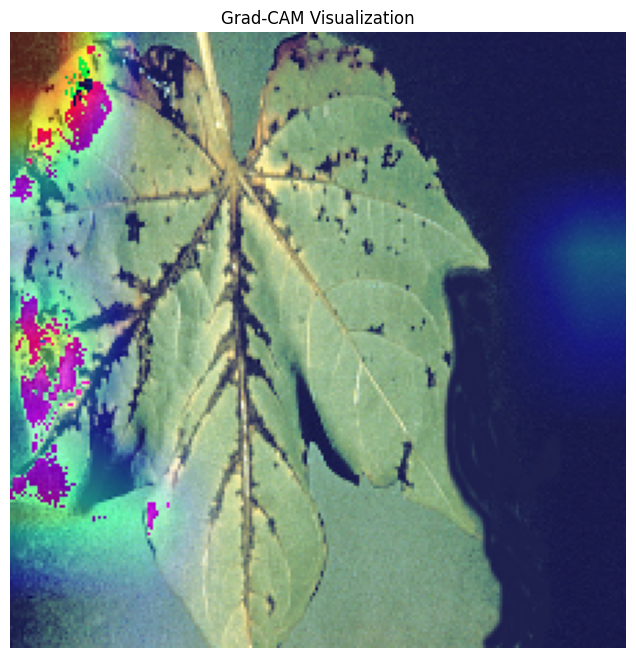

In [ ]:
img = cv2.imread(img_path)

img = cv2.resize(img, (224, 224))

heatmap = cv2.resize(heatmap, (224, 224))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))

plt.axis('off')

plt.title("Grad-CAM Visualization")

plt.show()

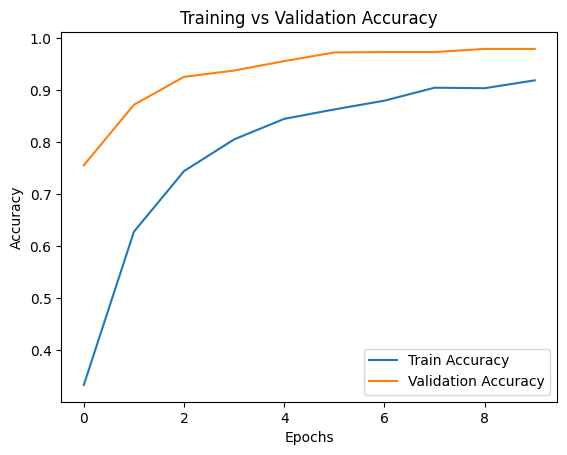

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.title('Training vs Validation Accuracy')

plt.savefig('accuracy.png')

plt.show()

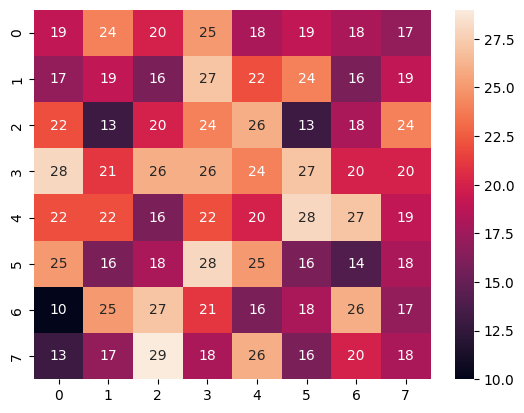

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True)

plt.savefig("confusion_matrix.png")

# EfficientNetB0

In [ ]:
pip install tensorflow matplotlib numpy opencv-python scikit-learn

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d saeedazfar/customized-cotton-disease-dataset

In [ ]:
!unzip customized-cotton-disease-dataset.zip
!ls

In [ ]:
!pip install tensorflow
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

In [ ]:
dataset_path = "/content/Customized Cotton Disease Dataset"

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 6628 files belonging to 8 classes.
Using 5303 files for training.
Found 6628 files belonging to 8 classes.
Using 1325 files for validation.
